In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('retail_fraud_detection_100k.csv') 

In [2]:
print(df.shape) 
print(df.columns.tolist())
print(df['fraud_flag'].value_counts())

(100000, 21)
['transaction_id', 'customer_id', 'transaction_timestamp', 'transaction_amount', 'payment_method', 'device_type', 'location', 'merchant_category', 'is_international', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'multiple_transactions_short_time', 'high_risk_device_flag', 'velocity_flag', 'fraud_flag', 'fraud_risk']
fraud_flag
0    52492
1    47508
Name: count, dtype: int64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   transaction_id                    100000 non-null  object 
 1   customer_id                       100000 non-null  object 
 2   transaction_timestamp             100000 non-null  object 
 3   transaction_amount                100000 non-null  float64
 4   payment_method                    100000 non-null  object 
 5   device_type                       100000 non-null  object 
 6   location                          100000 non-null  object 
 7   merchant_category                 100000 non-null  object 
 8   is_international                  100000 non-null  int64  
 9   transaction_frequency_24h         100000 non-null  int64  
 10  avg_transaction_amount_7d         100000 non-null  float64
 11  failed_transaction_count_24h      100000 non-null  in

In [4]:
df.describe()

,transaction_amount,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,120.475407,0.498010,7.489910,109.810966,2.003560,1005.329380,0.500150,0.229530,0.498010,0.427040,0.100960,0.283980,0.475080
std,119.787252,0.499999,4.024028,51.892854,1.414923,573.313726,0.500002,0.420533,0.499999,0.494651,0.301277,0.450929,0.499381
min,0.000000,0.000000,1.000000,20.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.820000,0.000000,4.000000,64.910000,1.000000,510.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,84.130000,0.000000,7.000000,109.780000,2.000000,1004.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,167.520000,1.000000,11.000000,154.672500,3.000000,1501.250000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1548.520000,1.000000,14.000000,200.000000,4.000000,1999.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.isnull().sum()

transaction_id                      0
customer_id                         0
transaction_timestamp               0
transaction_amount                  0
payment_method                      0
device_type                         0
location                            0
merchant_category                   0
is_international                    0
transaction_frequency_24h           0
avg_transaction_amount_7d           0
failed_transaction_count_24h        0
account_age_days                    0
previous_fraud_flag                 0
unusual_amount_flag                 0
unusual_location_flag               0
multiple_transactions_short_time    0
high_risk_device_flag               0
velocity_flag                       0
fraud_flag                          0
fraud_risk                          0
dtype: int64

In [6]:
df.head()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,3,866,0,0,0,1,0,0,0,Low


In [7]:
print(df['customer_id'].value_counts())
customer = df[df['customer_id'] == 'C28986'].copy()
customer['transaction_timestamp'] = pd.to_datetime(customer['transaction_timestamp'])
customer = customer.sort_values('transaction_timestamp')
customer

customer_id
C28986    13
C00353    13
C06084    12
C05168    12
C28630    12
          ..
C11298     1
C05639     1
C22502     1
C07843     1
C24689     1
Name: count, Length: 28955, dtype: int64


,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
57966,T0057967,C28986,2025-05-10 19:56:24.868268,51.70,Credit Card,Desktop,India,Fashion,0,11,...,1,1179,1,0,0,1,0,1,1,Medium
29715,T0029716,C28986,2025-08-16 19:56:24.293105,55.59,PayPal,Mobile,Australia,Gaming,0,10,...,3,1534,1,0,0,1,0,0,1,Medium
69450,T0069451,C28986,2025-09-03 19:56:25.130458,74.39,Credit Card,Desktop,UK,Travel,1,1,...,2,1741,1,0,1,0,0,0,1,Medium
81602,T0081603,C28986,2025-09-29 19:56:25.387752,114.08,Debit Card,Tablet,Australia,Travel,0,2,...,3,105,0,0,0,0,0,0,0,Low
34334,T0034335,C28986,2025-10-03 19:56:24.387742,42.42,PayPal,Tablet,India,Electronics,1,3,...,1,165,0,0,1,0,0,0,0,Low
18689,T0018690,C28986,2025-11-07 19:56:24.066888,109.25,Credit Card,Mobile,Canada,Electronics,0,6,...,4,732,0,0,0,0,0,0,0,Low
72210,T0072211,C28986,2025-11-17 19:56:25.190354,188.06,PayPal,Tablet,Australia,Electronics,0,1,...,2,1507,0,1,0,0,0,0,0,Low
64182,T0064183,C28986,2025-12-21 19:56:25.019501,102.59,Apple Pay,Desktop,UK,Groceries,0,8,...,1,475,0,0,0,0,0,0,0,Low
25324,T0025325,C28986,2025-12-30 19:56:24.201315,101.96,Apple Pay,Tablet,Germany,Luxury,1,2,...,2,308,0,0,1,0,0,0,0,Low
91001,T0091002,C28986,2026-02-05 19:56:25.584383,13.83,Apple Pay,Desktop,Australia,Travel,0,3,...,4,354,1,0,0,0,0,0,0,Medium


In [8]:
# Shows that all transactions are at 19:00 (7PM)
df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'])
df_eda = df.copy()
df_eda['hour'] = df_eda['transaction_timestamp'].dt.hour
df_eda['day_of_week'] = df_eda['transaction_timestamp'].dt.dayofweek
df_eda['month'] = df_eda['transaction_timestamp'].dt.month
print(df_eda['hour'].value_counts().sort_index())

hour
19    100000
Name: count, dtype: int64


In [9]:
#Figure 4: correlations
# Correlation of numerical features with fraud_flag
numeric_cols = df.select_dtypes(include = ['int64', 'float64']).columns
correlations = df[numeric_cols].corr()['fraud_flag'].sort_values(ascending = False)
print(correlations)

fraud_flag                          1.000000
previous_fraud_flag                 0.423561
is_international                    0.422911
unusual_location_flag               0.422911
multiple_transactions_short_time    0.348364
unusual_amount_flag                 0.329398
velocity_flag                       0.326297
transaction_frequency_24h           0.324047
failed_transaction_count_24h        0.228550
transaction_amount                  0.206105
high_risk_device_flag               0.126393
account_age_days                   -0.002136
avg_transaction_amount_7d          -0.138906
Name: fraud_flag, dtype: float64


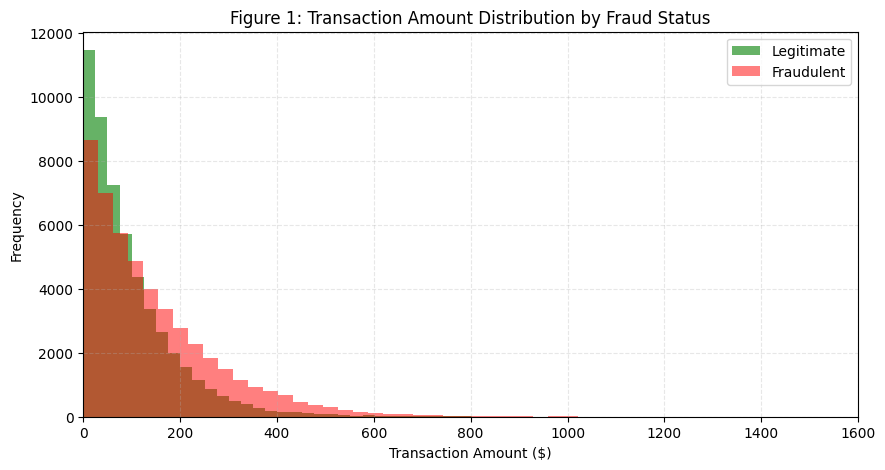

In [10]:
# Figure 1: Transaction Amount Distribution
plt.figure(figsize=(10,5))
plt.hist(df[df['fraud_flag']== 0]['transaction_amount'], bins = 50, alpha = 0.6, label = 'Legitimate', color = 'green', linewidth = 0.5)
plt.hist(df[df['fraud_flag']== 1]['transaction_amount'], bins = 50, alpha = 0.5, label = 'Fraudulent', color = 'red', linewidth = 0.5)
plt.title('Figure 1: Transaction Amount Distribution by Fraud Status')
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, 1600)
plt.grid(True, alpha = 0.3, linestyle = '--')
# plt.savefig('figure1_amount_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
df_display = df.copy()
df_display['fraud_flag'] = df_display['fraud_flag'].map({0: 'Not Fraud', 1: 'Fraud'})
df_display['is_international'] = df_display['is_international'].map({0: 'Domestic', 1: 'International'})
df_display['previous_fraud_flag'] = df_display['previous_fraud_flag'].map({0: 'No Previous Fraud', 1: 'Previous Fraud'})

# Figure 2: International status vs fraud_flag
table1 = pd.crosstab(df_display['is_international'], df_display['fraud_flag'], normalize = 'index')
table1 = table1.map(lambda x: f"{x:.1%}")
table1

fraud_flag,Fraud,Not Fraud
is_international,,
Domestic,26.5%,73.5%
International,68.7%,31.3%


In [12]:
# Figure 3: Previous fraud flag vs fraud_flag
table2 = pd.crosstab(df_display['previous_fraud_flag'], df_display['fraud_flag'], normalize = 'index')
table2 = table2.map(lambda x: f"{x:.1%}")
table2

fraud_flag,Fraud,Not Fraud
previous_fraud_flag,,
No Previous Fraud,26.3%,73.7%
Previous Fraud,68.7%,31.3%


In [13]:
# zero-amount transactions
zero_amount = df[df['transaction_amount'] == 0]
zero_amount['fraud_flag']

33919    0
37953    1
39684    0
40305    1
Name: fraud_flag, dtype: int64

In [14]:
# Independence
table3 = pd.crosstab(df_display['previous_fraud_flag'], df_display['is_international'], normalize = 'index')
table3 = table3.map(lambda x: f"{x:.1%}")
table3

is_international,Domestic,International
previous_fraud_flag,,
No Previous Fraud,50.5%,49.5%
Previous Fraud,49.9%,50.1%
